In [1]:
# =============================================================================
# NOTEBOOK 03b: STAGE 2 RE-RUN — Conservative Fine-Tuning
# =============================================================================
# Re-runs EfficientNet-B0 and MobileNetV2 experiments with:
#   - 10% layer unfreeze (instead of 30%)
#   - BatchNorm layers kept frozen during Phase B
#
# This addresses the Phase B instability observed in the original Stage 2 runs.

In [2]:
from utils import *
 
print("Classes:", CLASS_NAMES)
print("GPU:", tf.config.list_physical_devices('GPU'))

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
GPU: []


In [3]:
class_weights = compute_class_weights()
 
raw_train = load_base_dataset(TRAIN_DIR, shuffle=True)
raw_val   = load_base_dataset(VAL_DIR, shuffle=False)
raw_test  = load_base_dataset(TEST_DIR, shuffle=False)
 
val_ds  = build_dataset_no_aug(raw_val, shuffle=False)
test_ds = build_dataset_no_aug(raw_test, shuffle=False)
 
train_ds_basic    = build_dataset_traditional_aug(raw_train)
train_ds_advanced = build_dataset_mixup_cutmix(raw_train)
 
print("All datasets ready.")

Found 8012 files belonging to 7 classes.
Found 1001 files belonging to 7 classes.
Found 1002 files belonging to 7 classes.
All datasets ready.



############################################################
  EXPERIMENT: exp4a_v2_efficientnetb0_basic_aug
############################################################



wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/emiryscn/.netrc.
wandb: Currently logged in as: emiryscn (emiryscn-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


EfficientNet-B0 built. Base layers: 238, Total params: 4,379,306

--- PHASE A: Feature Extraction (Frozen Base) ---
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 61s 229ms/step - accuracy: 0.4296 - loss: 1.5621 - val_accuracy: 0.6014 - val_loss: 1.0421 - learning_rate: 0.0010
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 227ms/step - accuracy: 0.5206 - loss: 1.2576 - val_accuracy: 0.5345 - val_loss: 1.1211 - learning_rate: 0.0010
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 60s 233ms/step - accuracy: 0.5407 - loss: 1.1656 - val_accuracy: 0.6484 - val_loss: 0.9182 - learning_rate: 0.0010
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 59s 230ms/step - accuracy: 0.5639 - loss: 1.0733 - val_accuracy: 0.6533 - val_loss: 0.8892 - learning_rate: 0.0010
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 226ms/step - accuracy: 0.5696 - loss: 1.0565 - val_accuracy: 0.5724 - val_loss: 1.0460 - learning_rate: 0.0010
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 59s 230ms/step - accuracy: 0.5625 - loss: 1.0398 - val_accuracy: 0.65

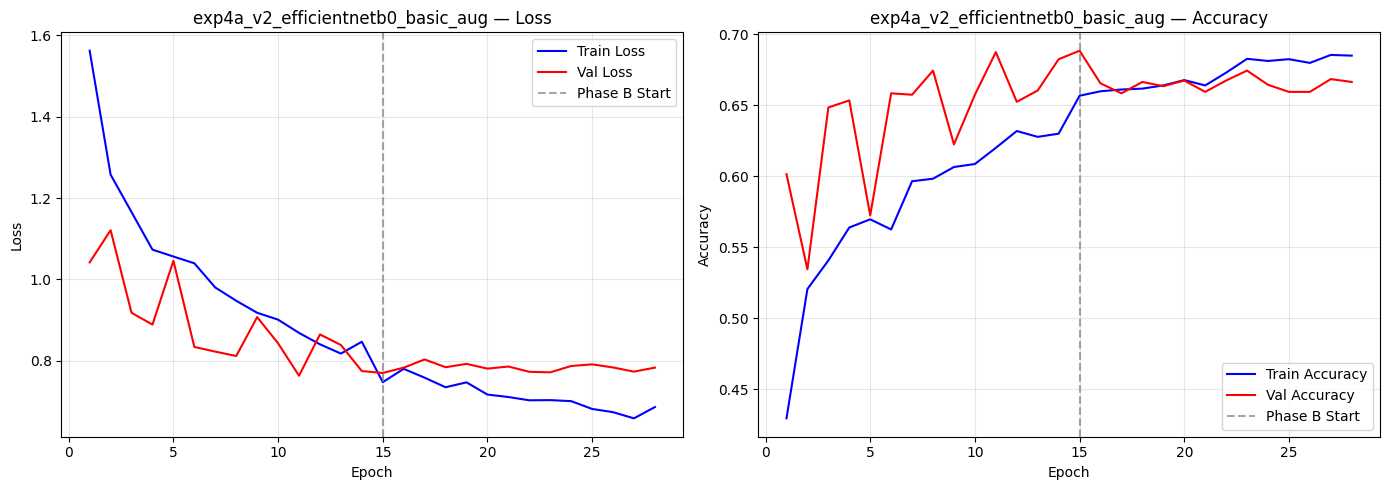


Model saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/models/exp4a_v2_efficientnetb0_basic_aug_final.keras

  EVALUATION: exp4a_v2_efficientnetb0_basic_aug

              precision    recall  f1-score   support

       akiec     0.5909    0.3939    0.4727        33
         bcc     0.6970    0.4510    0.5476        51
         bkl     0.4471    0.6909    0.5429       110
          df     0.3200    0.6667    0.4324        12
         mel     0.2840    0.6396    0.3934       111
          nv     0.9504    0.6855    0.7965       671
        vasc     0.6667    0.8571    0.7500        14

    accuracy                         0.6617      1002
   macro avg     0.5651    0.6264    0.5622      1002
weighted avg     0.7851    0.6617    0.6957      1002



2026-03-14 01:17:49.078333: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


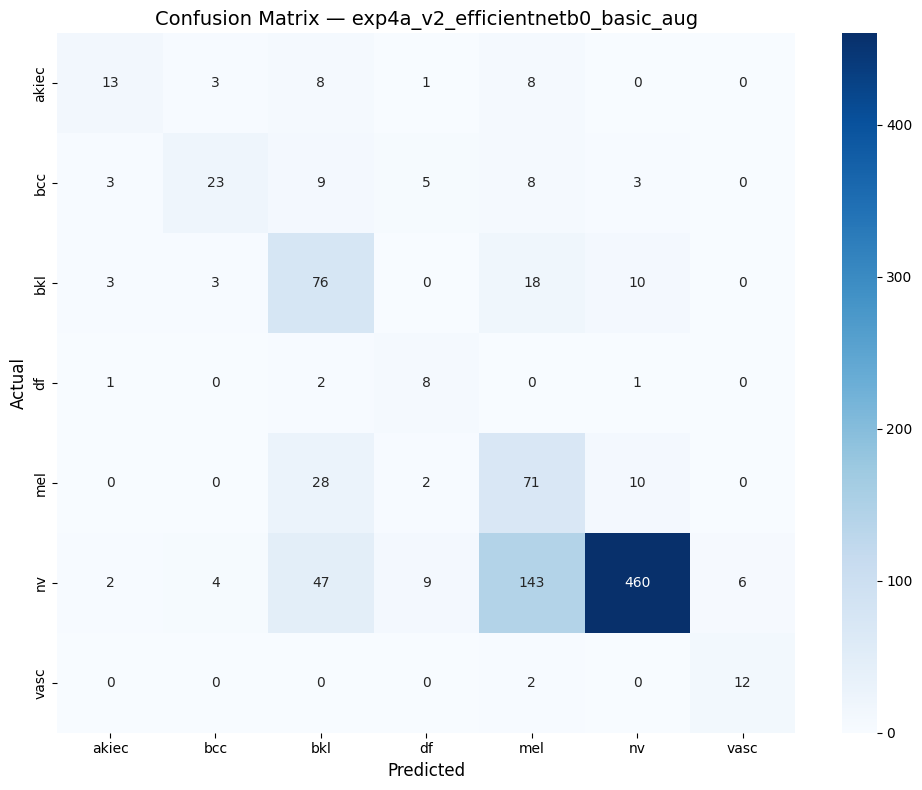

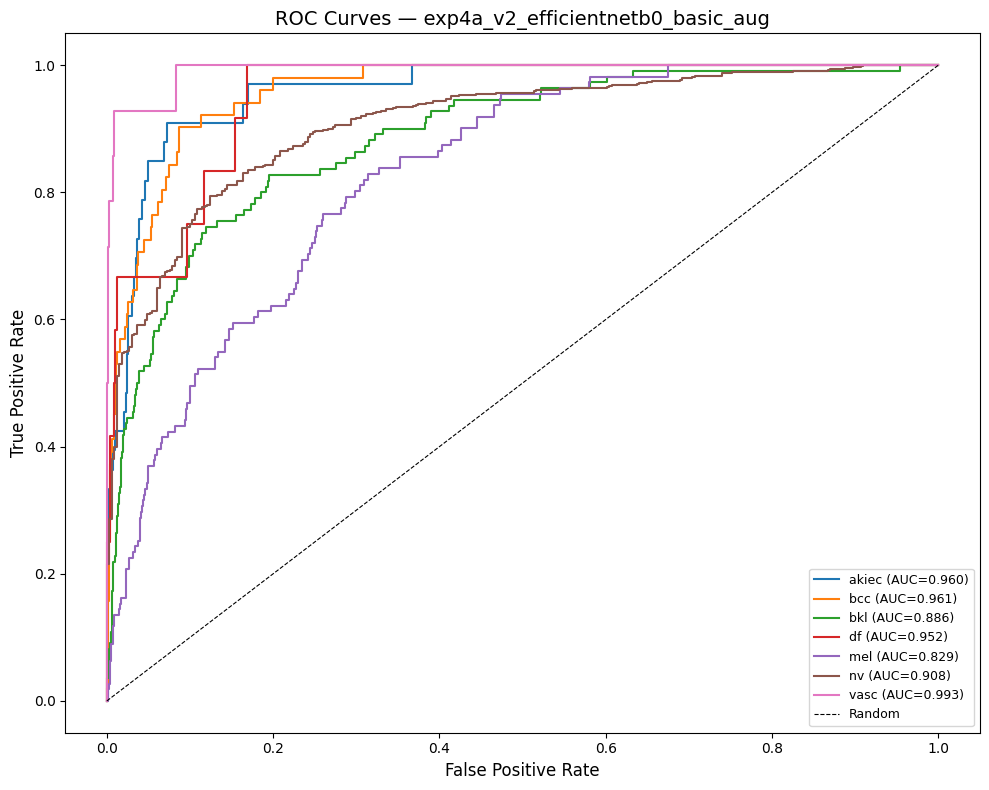


--- KEY METRICS ---
  Overall Accuracy:  0.6617
  Macro F1-Score:    0.5622
  Macro Recall:      0.6264
  Mean AUC-ROC:      0.9270
  Melanoma Recall:   0.6396  ← CRITICAL
  Melanoma F1:       0.3934

  Results saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/exp4a_v2_efficientnetb0_basic_aug_*


epoch/accuracy,▁▃▄▅▅▅▆▆▆▆▆▇▆▆▇▇▇▇▇█▇███████
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█▁▁▂▃▃▃▄▅▅▅▆▇▇
epoch/learning_rate,█████████████▄▄▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▄▁▆▆▃▇▇▇▅▇█▆▇██▇▇▇▇▇▇▇▇▇▇▇▇▇
epoch/val_loss,▆█▄▃▇▂▂▂▄▃▁▃▂▁▁▁▂▁▂▁▁▁▁▁▂▁▁▁
test/accuracy,▁
test/macro_f1,▁
test/macro_recall,▁
test/mean_auc,▁
+2,...



  exp4a_v2_efficientnetb0_basic_aug COMPLETE



In [4]:
# EXP 4a_v2: EfficientNet-B0 + Traditional Aug (Conservative FT)
# =============================================================================
# Changes from original: unfreeze_pct=0.10, freeze_bn=True
 
model_effnet_basic_v2, summary_effnet_basic_v2 = run_experiment(
    experiment_name="exp4a_v2_efficientnetb0_basic_aug",
    train_ds=train_ds_basic,
    val_ds=val_ds,
    test_ds=test_ds,
    build_model_fn=build_efficientnetb0,
    class_weights=class_weights,
    use_class_weights=True,
    architecture_name="EfficientNet-B0",
    unfreeze_pct=0.10,
    freeze_bn=True
)
 


############################################################
  EXPERIMENT: exp4b_v2_efficientnetb0_mixup_cutmix
############################################################



EfficientNet-B0 built. Base layers: 238, Total params: 4,379,306

--- PHASE A: Feature Extraction (Frozen Base) ---
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 230ms/step - accuracy: 0.6790 - loss: 0.9855 - val_accuracy: 0.6913 - val_loss: 0.8413 - learning_rate: 0.0010
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 59s 230ms/step - accuracy: 0.7023 - loss: 0.9031 - val_accuracy: 0.7163 - val_loss: 0.7433 - learning_rate: 0.0010
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 59s 232ms/step - accuracy: 0.7098 - loss: 0.8711 - val_accuracy: 0.7203 - val_loss: 0.7125 - learning_rate: 0.0010
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 225ms/step - accuracy: 0.7152 - loss: 0.8674 - val_accuracy: 0.7502 - val_loss: 0.6791 - learning_rate: 0.0010
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 227ms/step - accuracy: 0.7198 - loss: 0.8604 - val_accuracy: 0.7333 - val_loss: 0.7311 - learning_rate: 0.0010
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 59s 229ms/step - accuracy: 0.7158 - loss: 0.8506 - val_accuracy: 0.74

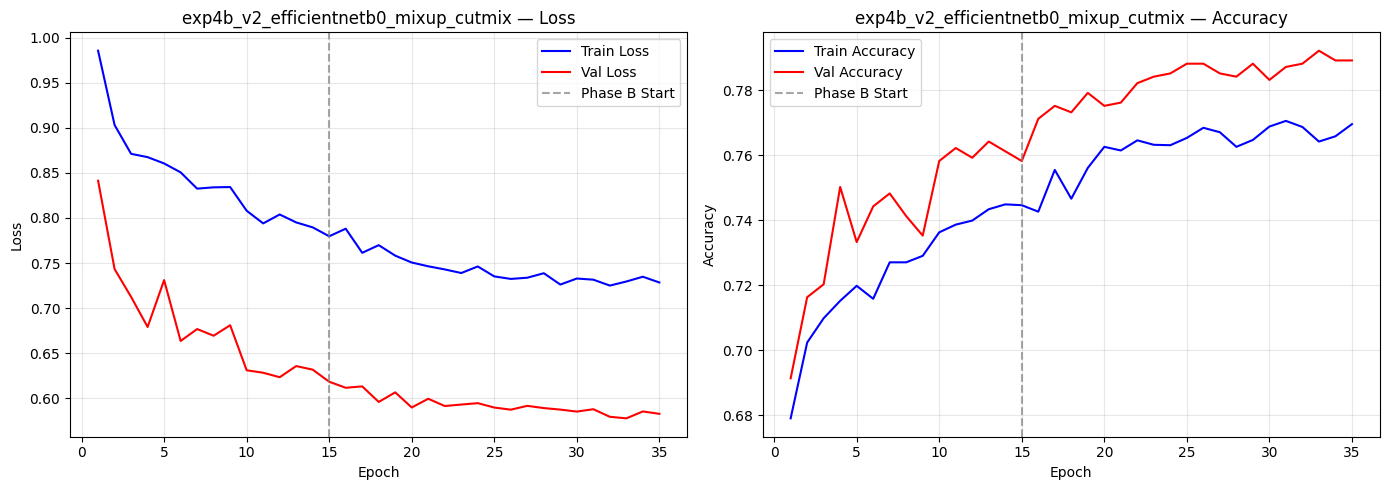


Model saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/models/exp4b_v2_efficientnetb0_mixup_cutmix_final.keras

  EVALUATION: exp4b_v2_efficientnetb0_mixup_cutmix

              precision    recall  f1-score   support

       akiec     0.6364    0.2121    0.3182        33
         bcc     0.8261    0.3725    0.5135        51
         bkl     0.5172    0.6818    0.5882       110
          df     1.0000    0.2500    0.4000        12
         mel     0.5000    0.3964    0.4422       111
          nv     0.8649    0.9255    0.8942       671
        vasc     0.8571    0.8571    0.8571        14

    accuracy                         0.7794      1002
   macro avg     0.7431    0.5279    0.5734      1002
weighted avg     0.7783    0.7794    0.7657      1002



2026-03-14 02:01:27.951559: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


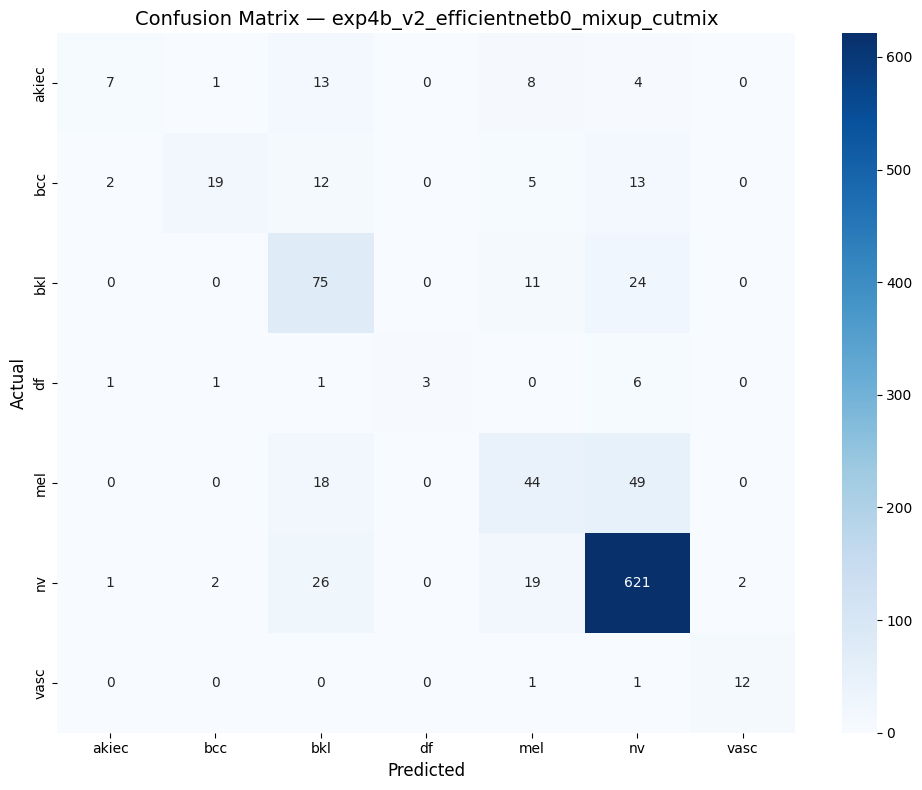

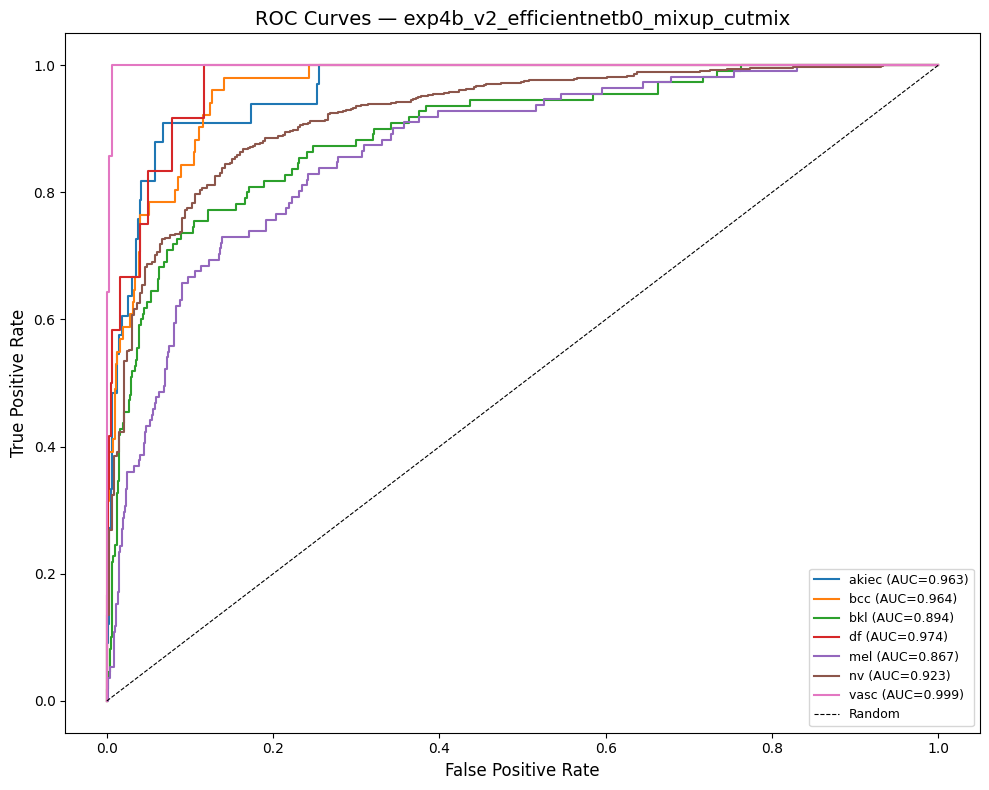


--- KEY METRICS ---
  Overall Accuracy:  0.7794
  Macro F1-Score:    0.5734
  Macro Recall:      0.5279
  Mean AUC-ROC:      0.9406
  Melanoma Recall:   0.3964  ← CRITICAL
  Melanoma F1:       0.4422

  Results saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/exp4b_v2_efficientnetb0_mixup_cutmix_*


epoch/accuracy,▁▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▇▆▇▇▇█▇▇███▇███████
epoch/epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
epoch/learning_rate,████████▄▄▄▄▄▄▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▅▅▄▄▄▄▃▃▃▃▃▂▃▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▃▅▄▅▅▄▄▆▆▆▆▆▆▇▇▇▇▇▇▇▇████▇█▇█████
epoch/val_loss,█▅▅▄▅▃▄▃▄▂▂▂▃▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁
test/macro_f1,▁
test/macro_recall,▁
test/mean_auc,▁
+2,...



  exp4b_v2_efficientnetb0_mixup_cutmix COMPLETE



In [5]:
# EXP 4b_v2: EfficientNet-B0 + MixUp/CutMix (Conservative FT)
# =============================================================================
 
model_effnet_mixup_v2, summary_effnet_mixup_v2 = run_experiment(
    experiment_name="exp4b_v2_efficientnetb0_mixup_cutmix",
    train_ds=train_ds_advanced,
    val_ds=val_ds,
    test_ds=test_ds,
    build_model_fn=build_efficientnetb0,
    class_weights=class_weights,
    use_class_weights=False,
    architecture_name="EfficientNet-B0",
    unfreeze_pct=0.10,
    freeze_bn=True
)


############################################################
  EXPERIMENT: exp5a_v2_mobilenetv2_basic_aug
############################################################



MobileNetV2 built. Base layers: 154, Total params: 2,587,719

--- PHASE A: Feature Extraction (Frozen Base) ---
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 39s 147ms/step - accuracy: 0.4608 - loss: 1.5874 - val_accuracy: 0.3926 - val_loss: 1.4587 - learning_rate: 0.0010
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 147ms/step - accuracy: 0.4961 - loss: 1.3198 - val_accuracy: 0.5804 - val_loss: 1.1271 - learning_rate: 0.0010
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 147ms/step - accuracy: 0.5382 - loss: 1.1965 - val_accuracy: 0.6054 - val_loss: 1.0844 - learning_rate: 0.0010
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 147ms/step - accuracy: 0.5588 - loss: 1.1072 - val_accuracy: 0.5604 - val_loss: 1.1640 - learning_rate: 0.0010
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 147ms/step - accuracy: 0.5779 - loss: 1.0232 - val_accuracy: 0.6713 - val_loss: 0.8985 - learning_rate: 0.0010
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 37s 144ms/step - accuracy: 0.5881 - loss: 1.0128 - val_accuracy: 0.5834 -

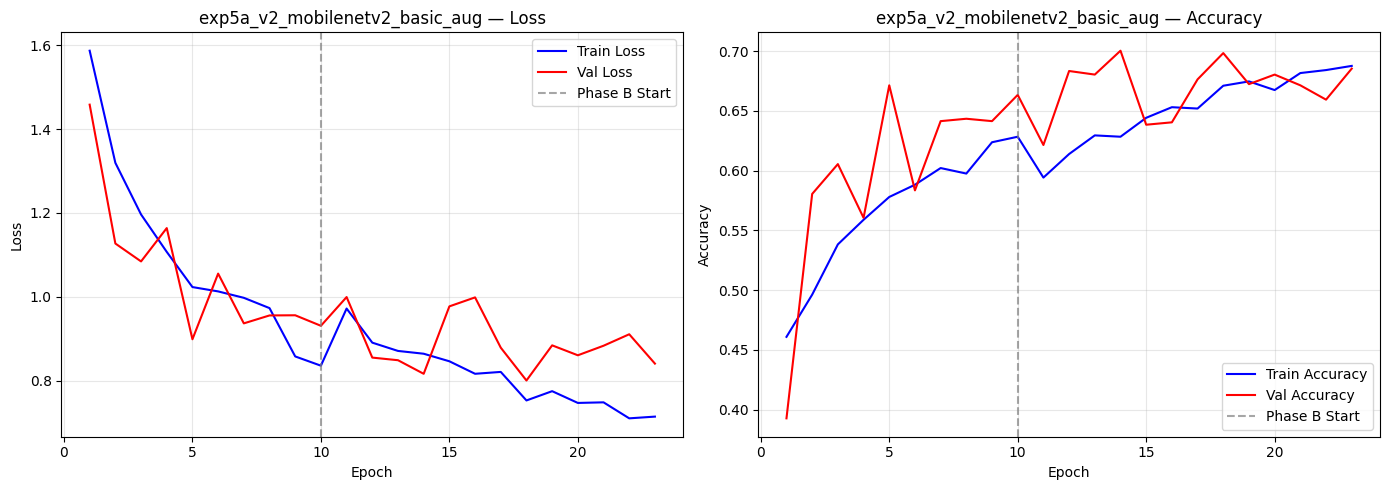


Model saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/models/exp5a_v2_mobilenetv2_basic_aug_final.keras

  EVALUATION: exp5a_v2_mobilenetv2_basic_aug

              precision    recall  f1-score   support

       akiec     0.5714    0.4848    0.5246        33
         bcc     0.6750    0.5294    0.5934        51
         bkl     0.3886    0.6818    0.4950       110
          df     0.3333    0.5833    0.4242        12
         mel     0.3827    0.5586    0.4542       111
          nv     0.9376    0.7392    0.8267       671
        vasc     0.3448    0.7143    0.4651        14

    accuracy                         0.6916      1002
   macro avg     0.5191    0.6131    0.5405      1002
weighted avg     0.7749    0.6916    0.7173      1002



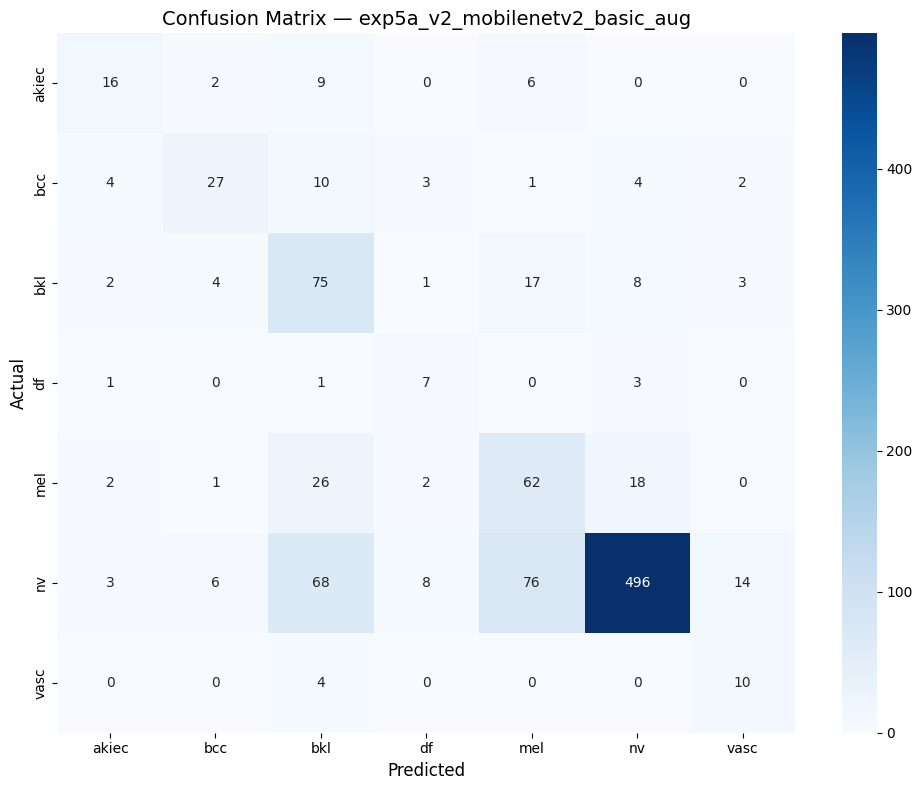

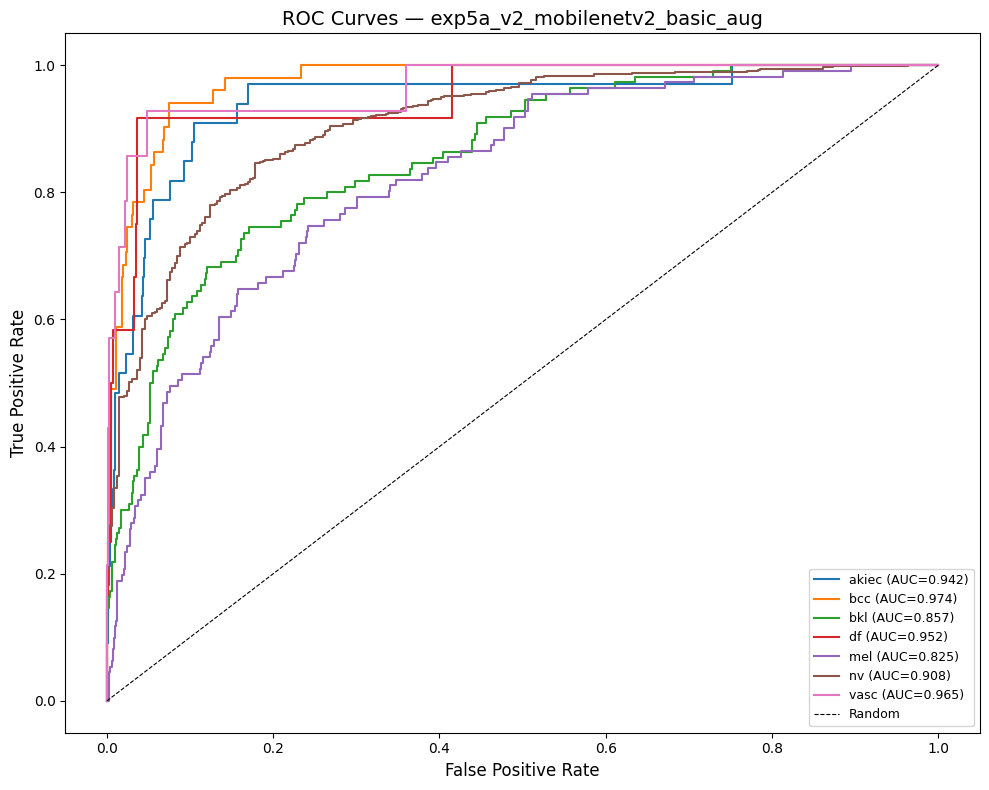


--- KEY METRICS ---
  Overall Accuracy:  0.6916
  Macro F1-Score:    0.5405
  Macro Recall:      0.6131
  Mean AUC-ROC:      0.9176
  Melanoma Recall:   0.5586  ← CRITICAL
  Melanoma F1:       0.4542

  Results saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/exp5a_v2_mobilenetv2_basic_aug_*


epoch/accuracy,▁▂▃▄▅▅▅▅▆▆▅▆▆▆▇▇▇▇█▇███
epoch/epoch,▁▂▂▃▃▄▅▅▆▆▁▂▂▃▃▄▅▅▆▆▇▇█
epoch/learning_rate,███████▄▄▄▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▃▃▃▃▂▂▃▂▂▂▂▂▂▁▂▁▁▁▁
epoch/val_accuracy,▁▅▆▅▇▅▇▇▇▇▆███▇▇▇█▇█▇▇█
epoch/val_loss,█▄▄▅▂▄▂▃▃▂▃▂▂▁▃▃▂▁▂▂▂▂▁
test/accuracy,▁
test/macro_f1,▁
test/macro_recall,▁
test/mean_auc,▁
+2,...



  exp5a_v2_mobilenetv2_basic_aug COMPLETE



In [6]:
# EXP 5a_v2: MobileNetV2 + Traditional Aug (Conservative FT)
# =============================================================================
 
model_mobile_basic_v2, summary_mobile_basic_v2 = run_experiment(
    experiment_name="exp5a_v2_mobilenetv2_basic_aug",
    train_ds=train_ds_basic,
    val_ds=val_ds,
    test_ds=test_ds,
    build_model_fn=build_mobilenetv2,
    class_weights=class_weights,
    use_class_weights=True,
    architecture_name="MobileNetV2",
    unfreeze_pct=0.10,
    freeze_bn=True
)


############################################################
  EXPERIMENT: exp5b_v2_mobilenetv2_mixup_cutmix
############################################################



MobileNetV2 built. Base layers: 154, Total params: 2,587,719

--- PHASE A: Feature Extraction (Frozen Base) ---
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 39s 147ms/step - accuracy: 0.6815 - loss: 1.0230 - val_accuracy: 0.7113 - val_loss: 0.7704 - learning_rate: 0.0010
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 145ms/step - accuracy: 0.6970 - loss: 0.9280 - val_accuracy: 0.7233 - val_loss: 0.7566 - learning_rate: 0.0010
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 145ms/step - accuracy: 0.7041 - loss: 0.9121 - val_accuracy: 0.7263 - val_loss: 0.7236 - learning_rate: 0.0010
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 145ms/step - accuracy: 0.7102 - loss: 0.8948 - val_accuracy: 0.7283 - val_loss: 0.7342 - learning_rate: 0.0010
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 37s 143ms/step - accuracy: 0.7158 - loss: 0.8861 - val_accuracy: 0.7233 - val_loss: 0.7246 - learning_rate: 0.0010
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 145ms/step - accuracy: 0.7154 - loss: 0.8725 - val_accuracy: 0.7383 -

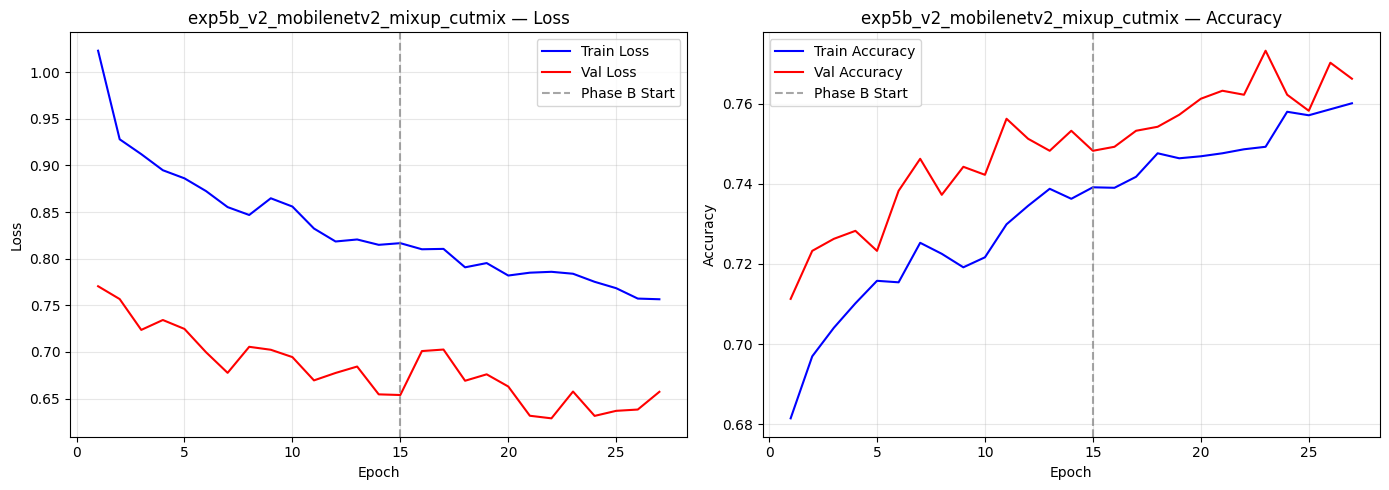


Model saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/models/exp5b_v2_mobilenetv2_mixup_cutmix_final.keras

  EVALUATION: exp5b_v2_mobilenetv2_mixup_cutmix

              precision    recall  f1-score   support

       akiec     0.7143    0.1515    0.2500        33
         bcc     0.7568    0.5490    0.6364        51
         bkl     0.5263    0.5455    0.5357       110
          df     0.0000    0.0000    0.0000        12
         mel     0.4211    0.1441    0.2148       111
          nv     0.8108    0.9583    0.8784       671
        vasc     0.7500    0.6429    0.6923        14

    accuracy                         0.7595      1002
   macro avg     0.5685    0.4273    0.4582      1002
weighted avg     0.7199    0.7595    0.7211      1002



2026-03-14 02:34:22.852891: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


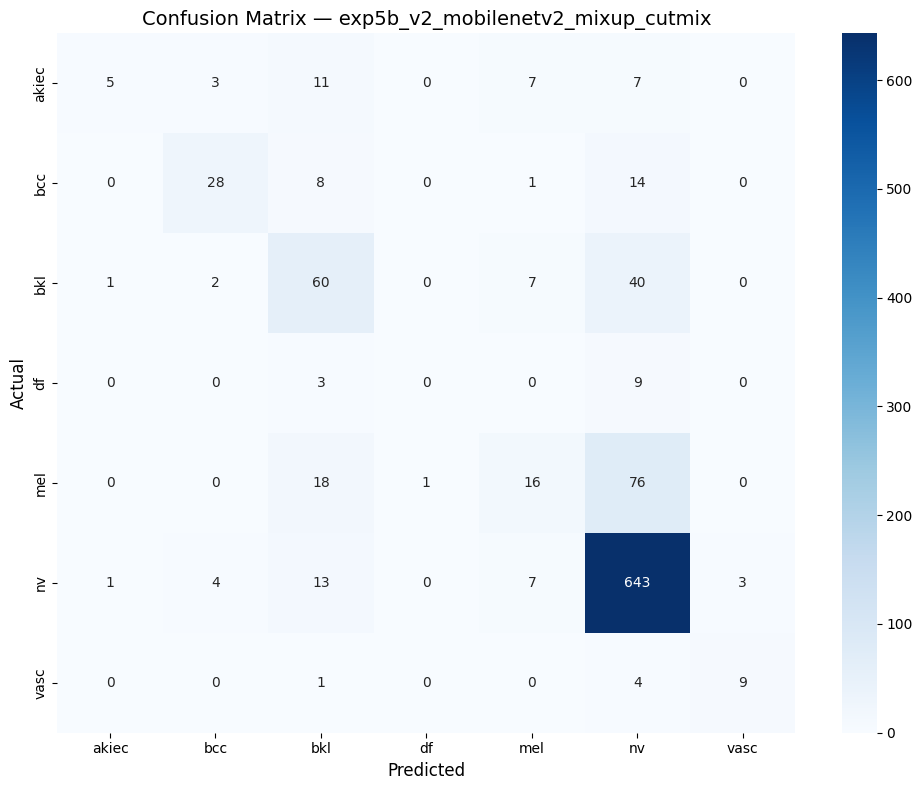

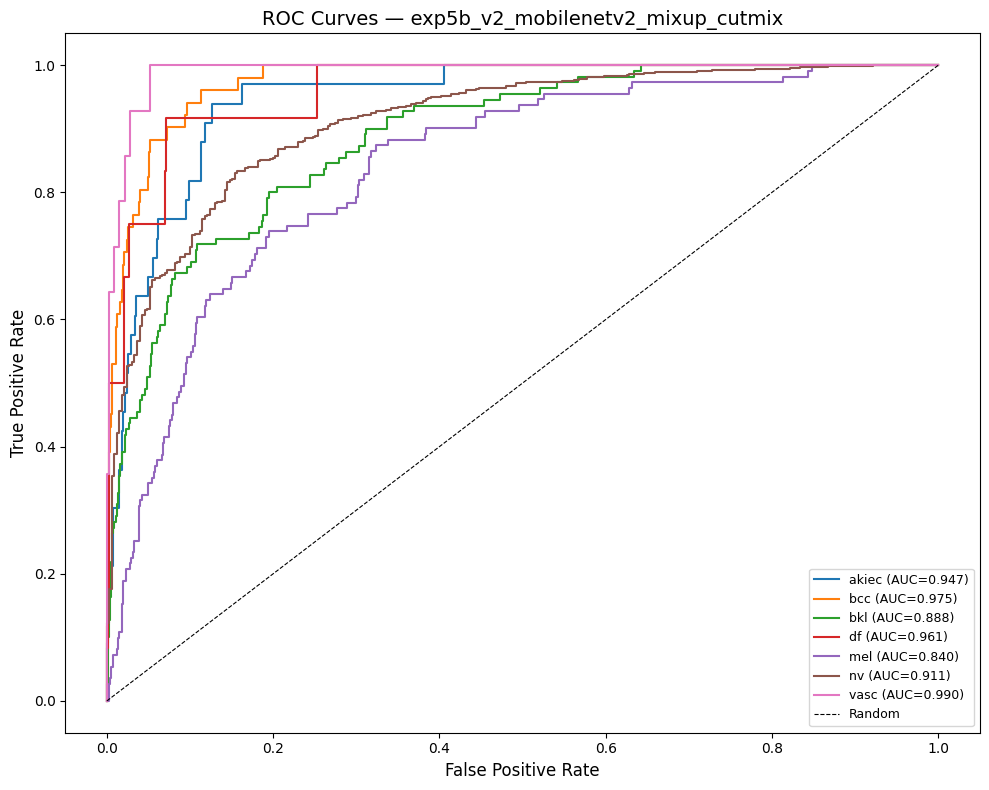


--- KEY METRICS ---
  Overall Accuracy:  0.7595
  Macro F1-Score:    0.4582
  Macro Recall:      0.4273
  Mean AUC-ROC:      0.9303
  Melanoma Recall:   0.1441  ← CRITICAL
  Melanoma F1:       0.2148

  Results saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/exp5b_v2_mobilenetv2_mixup_cutmix_*


epoch/accuracy,▁▂▃▄▄▄▅▅▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█▁▁▂▃▃▃▄▅▅▅▆▇
epoch/learning_rate,█████████▄▄▄▄▄▄▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▅▄▄▄▃▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁
epoch/val_accuracy,▁▂▃▃▂▄▅▄▅▄▆▆▅▆▅▅▆▆▆▇▇▇█▇▆█▇
epoch/val_loss,█▇▆▆▆▅▃▅▅▄▃▃▄▂▂▅▅▃▃▃▁▁▂▁▁▁▂
test/accuracy,▁
test/macro_f1,▁
test/macro_recall,▁
test/mean_auc,▁
+2,...



  exp5b_v2_mobilenetv2_mixup_cutmix COMPLETE



In [7]:
# EXP 5b_v2: MobileNetV2 + MixUp/CutMix (Conservative FT)
# =============================================================================
 
model_mobile_mixup_v2, summary_mobile_mixup_v2 = run_experiment(
    experiment_name="exp5b_v2_mobilenetv2_mixup_cutmix",
    train_ds=train_ds_advanced,
    val_ds=val_ds,
    test_ds=test_ds,
    build_model_fn=build_mobilenetv2,
    class_weights=class_weights,
    use_class_weights=False,
    architecture_name="MobileNetV2",
    unfreeze_pct=0.10,
    freeze_bn=True
)

In [8]:
# Compare v1 (30% unfreeze) vs v2 (10% + frozen BN)
# =============================================================================
# Load original results for comparison
 
original_names = [
    "exp4a_efficientnetb0_basic_aug",
    "exp4b_efficientnetb0_mixup_cutmix",
    "exp5a_mobilenetv2_basic_aug",
    "exp5b_mobilenetv2_mixup_cutmix",
]
 
original_summaries = []
for name in original_names:
    path = os.path.join(RESULTS_DIR, f"{name}_summary.json")
    with open(path, 'r') as f:
        original_summaries.append(json.load(f))
 
v2_summaries = [
    summary_effnet_basic_v2,
    summary_effnet_mixup_v2,
    summary_mobile_basic_v2,
    summary_mobile_mixup_v2,
]
 
print("\n" + "=" * 70)
print("  FINE-TUNING STRATEGY COMPARISON: 30% Unfreeze vs 10% + Frozen BN")
print("=" * 70)
 
for orig, v2 in zip(original_summaries, v2_summaries):
    arch = orig['experiment'].replace('exp4a_', '').replace('exp4b_', '').replace('exp5a_', '').replace('exp5b_', '')
    print(f"\n  {arch}:")
    print(f"    v1 (30%):        Macro F1={orig['macro_f1']:.4f}  Mel Recall={orig['mel_recall']:.4f}  Acc={orig['accuracy']:.4f}")
    print(f"    v2 (10%+BN):     Macro F1={v2['macro_f1']:.4f}  Mel Recall={v2['mel_recall']:.4f}  Acc={v2['accuracy']:.4f}")
    f1_change = v2['macro_f1'] - orig['macro_f1']
    mel_change = v2['mel_recall'] - orig['mel_recall']
    print(f"    Δ Macro F1: {f1_change:+.4f}  Δ Mel Recall: {mel_change:+.4f}")


  FINE-TUNING STRATEGY COMPARISON: 30% Unfreeze vs 10% + Frozen BN

  efficientnetb0_basic_aug:
    v1 (30%):        Macro F1=0.5113  Mel Recall=0.5135  Acc=0.6128
    v2 (10%+BN):     Macro F1=0.5622  Mel Recall=0.6396  Acc=0.6617
    Δ Macro F1: +0.0510  Δ Mel Recall: +0.1261

  efficientnetb0_mixup_cutmix:
    v1 (30%):        Macro F1=0.5155  Mel Recall=0.2973  Acc=0.7695
    v2 (10%+BN):     Macro F1=0.5734  Mel Recall=0.3964  Acc=0.7794
    Δ Macro F1: +0.0579  Δ Mel Recall: +0.0991

  mobilenetv2_basic_aug:
    v1 (30%):        Macro F1=0.4595  Mel Recall=0.4144  Acc=0.6507
    v2 (10%+BN):     Macro F1=0.5405  Mel Recall=0.5586  Acc=0.6916
    Δ Macro F1: +0.0810  Δ Mel Recall: +0.1441

  mobilenetv2_mixup_cutmix:
    v1 (30%):        Macro F1=0.5084  Mel Recall=0.3333  Acc=0.7824
    v2 (10%+BN):     Macro F1=0.4582  Mel Recall=0.1441  Acc=0.7595
    Δ Macro F1: -0.0502  Δ Mel Recall: -0.1892



  stage2_v2_final RESULTS COMPARISON
                          Experiment Accuracy Macro F1 Macro Recall Mean AUC Mel Recall Mel F1
             exp1_resnet50_basic_aug   0.7715   0.6887       0.7397   0.9545     0.8018 0.5914
          exp2_resnet50_mixup_cutmix   0.8313   0.6937       0.6465   0.9635     0.4775 0.5521
   exp4a_v2_efficientnetb0_basic_aug   0.6617   0.5622       0.6264   0.9270     0.6396 0.3934
exp4b_v2_efficientnetb0_mixup_cutmix   0.7794   0.5734       0.5279   0.9406     0.3964 0.4422
      exp5a_v2_mobilenetv2_basic_aug   0.6916   0.5405       0.6131   0.9176     0.5586 0.4542
   exp5b_v2_mobilenetv2_mixup_cutmix   0.7595   0.4582       0.4273   0.9303     0.1441 0.2148

--- Per-Class F1 Scores ---
       exp1_resnet50_basic_aug  exp2_resnet50_mixup_cutmix  exp4a_v2_efficientnetb0_basic_aug  exp4b_v2_efficientnetb0_mixup_cutmix  exp5a_v2_mobilenetv2_basic_aug  exp5b_v2_mobilenetv2_mixup_cutmix
akiec                 0.677966                    0.629630           

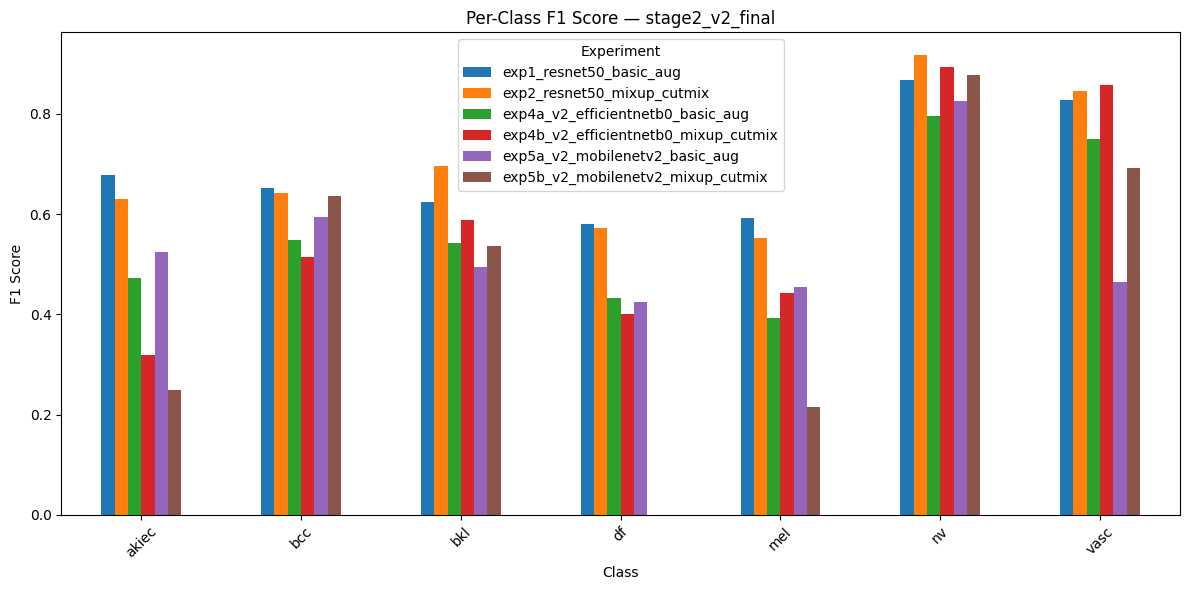


--- Per-Class Recall (Sensitivity) ---
       exp1_resnet50_basic_aug  exp2_resnet50_mixup_cutmix  exp4a_v2_efficientnetb0_basic_aug  exp4b_v2_efficientnetb0_mixup_cutmix  exp5a_v2_mobilenetv2_basic_aug  exp5b_v2_mobilenetv2_mixup_cutmix
akiec                 0.606061                    0.515152                           0.393939                              0.212121                        0.484848                           0.151515
bcc                   0.588235                    0.529412                           0.450980                              0.372549                        0.529412                           0.549020
bkl                   0.790909                    0.772727                           0.690909                              0.681818                        0.681818                           0.545455
df                    0.750000                    0.500000                           0.666667                              0.250000                        0.583333 

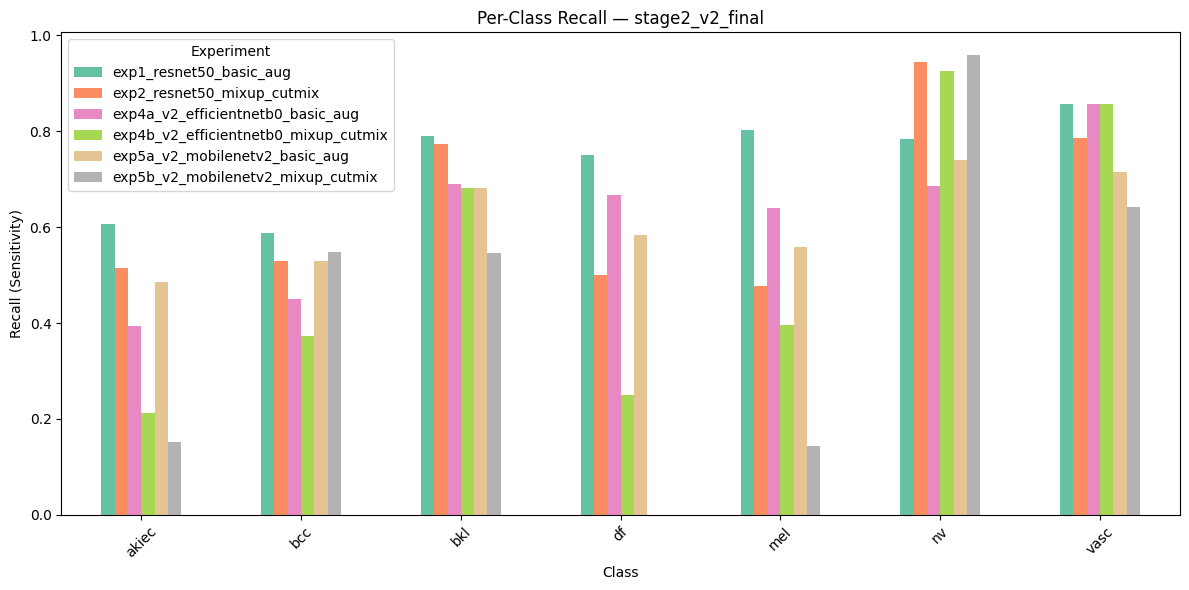

,Experiment,Accuracy,Macro F1,Macro Recall,Mean AUC,Mel Recall,Mel F1
0,exp1_resnet50_basic_aug,0.7715,0.6887,0.7397,0.9545,0.8018,0.5914
1,exp2_resnet50_mixup_cutmix,0.8313,0.6937,0.6465,0.9635,0.4775,0.5521
2,exp4a_v2_efficientnetb0_basic_aug,0.6617,0.5622,0.6264,0.9270,0.6396,0.3934
3,exp4b_v2_efficientnetb0_mixup_cutmix,0.7794,0.5734,0.5279,0.9406,0.3964,0.4422
4,exp5a_v2_mobilenetv2_basic_aug,0.6916,0.5405,0.6131,0.9176,0.5586,0.4542
5,exp5b_v2_mobilenetv2_mixup_cutmix,0.7595,0.4582,0.4273,0.9303,0.1441,0.2148


In [9]:
# UPDATED FULL STAGE 2 COMPARISON (All 6 Experiments — Best Versions)
# =============================================================================
# Use ResNet50 originals + v2 versions of EfficientNet and MobileNetV2
 
resnet_basic_path = os.path.join(RESULTS_DIR, "exp1_resnet50_basic_aug_summary.json")
resnet_mixup_path = os.path.join(RESULTS_DIR, "exp2_resnet50_mixup_cutmix_summary.json")
 
with open(resnet_basic_path, 'r') as f:
    summary_resnet_basic = json.load(f)
with open(resnet_mixup_path, 'r') as f:
    summary_resnet_mixup = json.load(f)
 
all_best_summaries = [
    summary_resnet_basic,
    summary_resnet_mixup,
    summary_effnet_basic_v2,
    summary_effnet_mixup_v2,
    summary_mobile_basic_v2,
    summary_mobile_mixup_v2,
]
 
compare_experiments(all_best_summaries, "stage2_v2_final")

In [10]:
# Select Best Model for Grad-CAM
# =============================================================================
 
print("\n" + "=" * 70)
print("  BEST MODEL SELECTION FOR STAGE 3 (GRAD-CAM)")
print("=" * 70)
 
best_f1_idx, best_f1 = select_best_experiment(all_best_summaries, 'macro_f1')
print(f"\n  Best by Macro F1: {best_f1['experiment']}")
 
best_mel_idx, best_mel = select_best_experiment(all_best_summaries, 'mel_recall')
print(f"  Best by Mel Recall: {best_mel['experiment']}")
 
if best_f1_idx == best_mel_idx:
    best_overall = best_f1
    print(f"\n  BOTH criteria agree → {best_overall['experiment']}")
else:
    print(f"\n  CRITERIA DISAGREE:")
    print(f"    Macro F1 winner:  {best_f1['experiment']} (F1={best_f1['macro_f1']:.4f}, MelRec={best_f1['mel_recall']:.4f})")
    print(f"    Mel Recall winner: {best_mel['experiment']} (F1={best_mel['macro_f1']:.4f}, MelRec={best_mel['mel_recall']:.4f})")
    print(f"\n  For a medical project, Melanoma Recall is the priority.")
    print(f"  → Recommended for Grad-CAM: {best_mel['experiment']}")
    best_overall = best_mel
 
with open(os.path.join(RESULTS_DIR, "stage2_v2_best_model.json"), 'w') as f:
    json.dump({
        "best_by_macro_f1": best_f1['experiment'],
        "best_by_mel_recall": best_mel['experiment'],
        "selected_for_gradcam": best_overall['experiment'],
        "macro_f1": float(best_overall['macro_f1']),
        "mel_recall": float(best_overall['mel_recall']),
        "mean_auc": float(best_overall['mean_auc']),
    }, f, indent=2)
 
print(f"\n  Decision saved to: {RESULTS_DIR}/stage2_v2_best_model.json")


  BEST MODEL SELECTION FOR STAGE 3 (GRAD-CAM)

  BEST EXPERIMENT (by macro_f1)
  Winner:       exp2_resnet50_mixup_cutmix
  Macro F1:     0.6937
  Mel Recall:   0.4775
  Mean AUC:     0.9635

  Best by Macro F1: exp2_resnet50_mixup_cutmix

  BEST EXPERIMENT (by mel_recall)
  Winner:       exp1_resnet50_basic_aug
  Macro F1:     0.6887
  Mel Recall:   0.8018
  Mean AUC:     0.9545
  Best by Mel Recall: exp1_resnet50_basic_aug

  CRITERIA DISAGREE:
    Macro F1 winner:  exp2_resnet50_mixup_cutmix (F1=0.6937, MelRec=0.4775)
    Mel Recall winner: exp1_resnet50_basic_aug (F1=0.6887, MelRec=0.8018)

  For a medical project, Melanoma Recall is the priority.
  → Recommended for Grad-CAM: exp1_resnet50_basic_aug

  Decision saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/stage2_v2_best_model.json


In [11]:
# Final Report Table
# =============================================================================
 
print("\n" + "=" * 70)
print("  UPDATED TABLE FOR FINAL REPORT")
print("=" * 70)
 
report_data = []
for s in all_best_summaries:
    name = s['experiment']
    if 'resnet' in name:
        arch = 'ResNet50'
        ft = '30% unfreeze'
    elif 'efficientnet' in name:
        arch = 'EfficientNet-B0'
        ft = '10% + frozen BN'
    else:
        arch = 'MobileNetV2'
        ft = '10% + frozen BN'
    
    strategy = 'MixUp/CutMix' if 'mixup' in name else 'Traditional Aug'
    
    report_data.append({
        'Architecture': arch,
        'Augmentation': strategy,
        'Fine-Tuning': ft,
        'Accuracy': f"{s['accuracy']:.4f}",
        'Macro F1': f"{s['macro_f1']:.4f}",
        'Mel Recall': f"{s['mel_recall']:.4f}",
        'Mean AUC': f"{s['mean_auc']:.4f}",
    })
 
report_df = pd.DataFrame(report_data)
print(report_df.to_string(index=False))
report_df.to_csv(os.path.join(RESULTS_DIR, "stage2_v2_report_table.csv"), index=False)
print(f"\nSaved to: {RESULTS_DIR}/stage2_v2_report_table.csv")


  UPDATED TABLE FOR FINAL REPORT
   Architecture    Augmentation     Fine-Tuning Accuracy Macro F1 Mel Recall Mean AUC
       ResNet50 Traditional Aug    30% unfreeze   0.7715   0.6887     0.8018   0.9545
       ResNet50    MixUp/CutMix    30% unfreeze   0.8313   0.6937     0.4775   0.9635
EfficientNet-B0 Traditional Aug 10% + frozen BN   0.6617   0.5622     0.6396   0.9270
EfficientNet-B0    MixUp/CutMix 10% + frozen BN   0.7794   0.5734     0.3964   0.9406
    MobileNetV2 Traditional Aug 10% + frozen BN   0.6916   0.5405     0.5586   0.9176
    MobileNetV2    MixUp/CutMix 10% + frozen BN   0.7595   0.4582     0.1441   0.9303

Saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/stage2_v2_report_table.csv
